In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

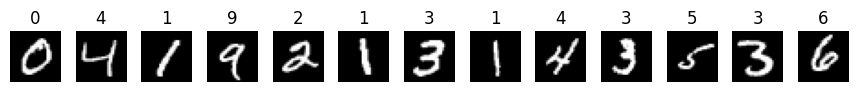

In [5]:
plt.figure(figsize=(10,2))
for i in range(1,14):
    plt.subplot(1,15,i+1)
    plt.imshow(x_train[i],cmap="grey")
    plt.axis("off")
    plt.title(str(y_train[i]))
plt.tight_layout()
plt.show()

In [6]:
print(tf.version)

<module 'tensorflow._api.v2.version' from 'c:\\Users\\kumar\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\tensorflow\\_api\\v2\\version\\__init__.py'>


In [7]:
tf1=tf.ones([2,2])

In [8]:
print(tf1)

tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32)


In [9]:
tf2=tf.reshape(tf1,[4,1])

In [10]:
print(tf2)

tf.Tensor(
[[1.]
 [1.]
 [1.]
 [1.]], shape=(4, 1), dtype=float32)


In [11]:
tf3=tf.zeros([5,5,5,5])
#print(tf3)
t=tf.reshape(tf3,[625])
#print(t)

In [12]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [13]:
x_train=x_train/255
x_test=x_test/255

In [14]:
x_train_flatten=x_train.reshape(len(x_train),28*28)
x_test_flatten=x_test.reshape(len(x_test),28*28)

In [15]:
x_test_flatten.shape

(10000, 784)

In [16]:
x_train_flatten[1]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [17]:
import keras

In [32]:
model=keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation="relu"),
    keras.layers.Dense(10,activation='sigmoid')
])

model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
model.fit(x_train_flatten,y_train,epochs=5,batch_size=10)


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9335 - loss: 0.2255
Epoch 2/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9700 - loss: 0.0992
Epoch 3/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9770 - loss: 0.0698
Epoch 4/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9828 - loss: 0.0529
Epoch 5/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9858 - loss: 0.0430


In [33]:
model.evaluate(x_test_flatten,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9764 - loss: 0.0792


[0.07918160408735275, 0.9764000177383423]

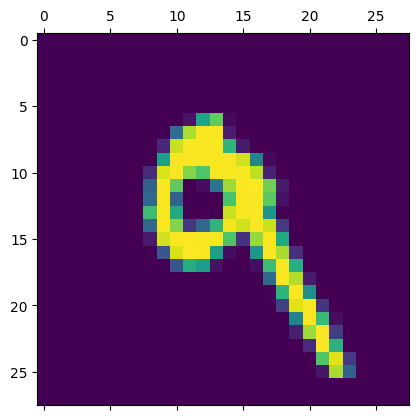

In [20]:
plt.matshow(x_test[7])

In [21]:
y_pre=model.predict(x_test_flatten)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step


In [22]:
import numpy as np

In [23]:
np.argmax(y_pre[7])

np.int64(9)

In [24]:
from sklearn.metrics import confusion_matrix

In [25]:

Y_pre=[np.argmax(i) for i in y_pre]

In [26]:
cm=confusion_matrix(y_test,Y_pre)

In [27]:
import seaborn as sns

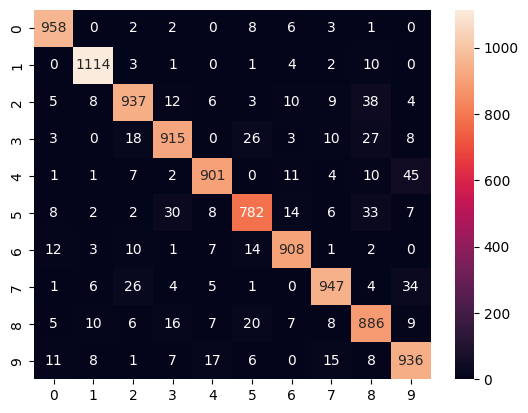

In [28]:
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [29]:
model=keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation="relu"),
    keras.layers.Dense(10,activation="sigmoid")
])

model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
model.fit(x_train_flatten,y_train,epochs=5)


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9207 - loss: 0.2782
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9627 - loss: 0.1281
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9737 - loss: 0.0885
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9792 - loss: 0.0678
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9835 - loss: 0.0530


In [30]:
model.evaluate(x_test_flatten,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9770 - loss: 0.0789


[0.07892907410860062, 0.9769999980926514]